<a href="https://colab.research.google.com/github/varnitjain8822/MACHINE-LEARNING-PROJECTS/blob/main/insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


In [ ]:
df.isnull().sum ()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
expenses,0


In [ ]:
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses'], dtype='object')

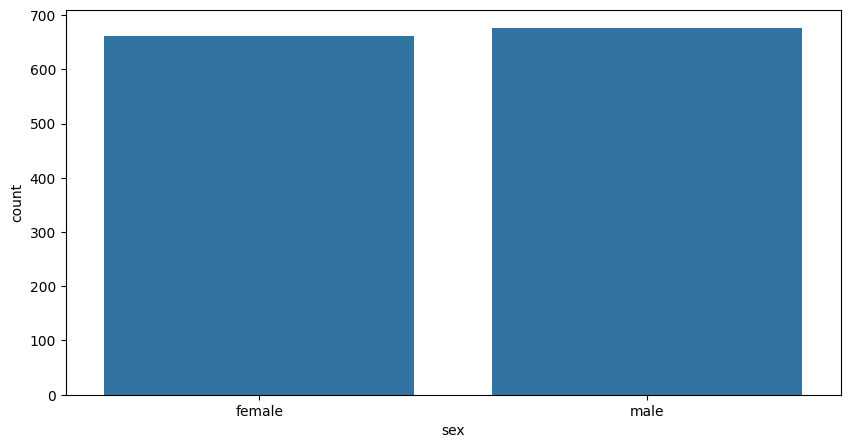

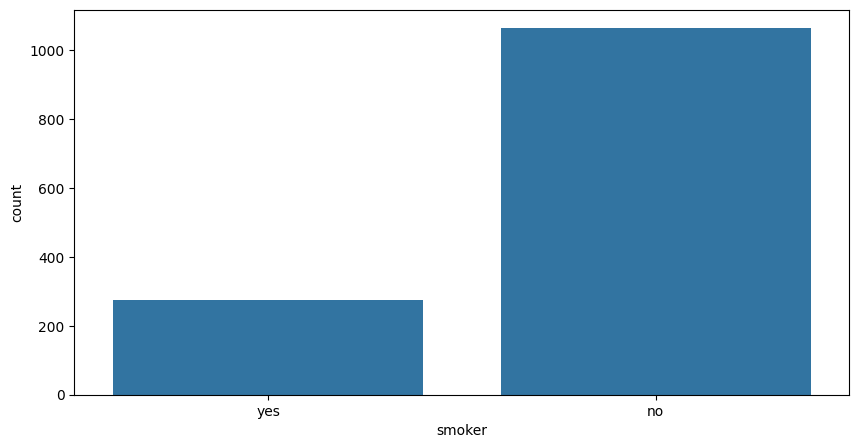

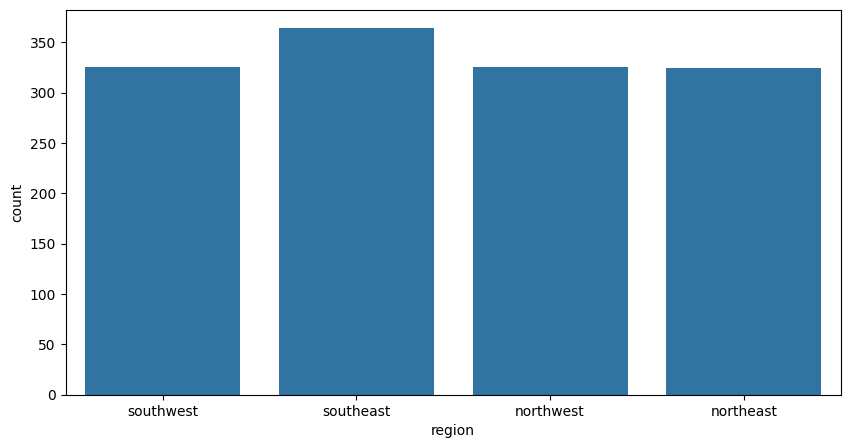

In [ ]:
from pandas.core.arrays import categorical
numeric_column=['age','bmi','children','expenses']
categorical_columns=['sex','smoker','region']
for col in categorical_columns:
  plt.figure(figsize=(10,5))
  sns.countplot(x=df[col])
  plt.show()

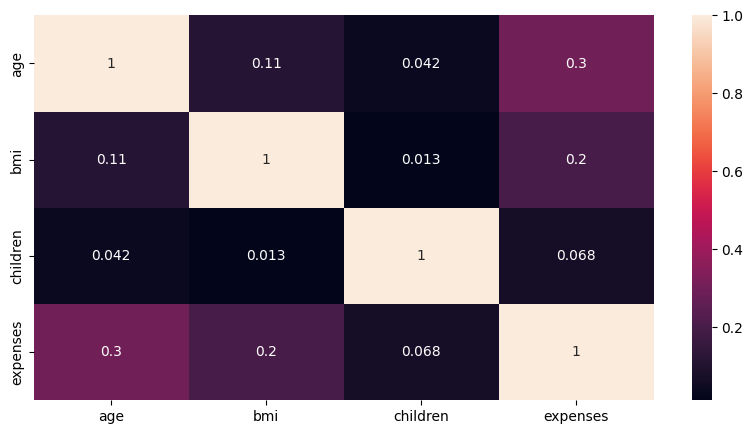

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df[numeric_column].corr(),annot=True)
plt.show()

In [ ]:
df_cleaned = df.copy()
df_cleaned.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [ ]:
df_cleaned.value_counts("sex")

,count
sex,
male,676
female,662


In [ ]:
df_cleaned['sex']=df_cleaned['sex'].map({'male':0,'female':1}).astype(int)

In [ ]:
df_cleaned['smoker']=df_cleaned['smoker'].map({'yes':1,'no':0})

In [ ]:
df_cleaned.rename(columns={'sex':'isfemale','smoker':'issmoker'},inplace=True)

In [ ]:
df_cleaned['isfemale'] = df_cleaned['isfemale'].astype(int)
df_cleaned['issmoker'] = df_cleaned['issmoker'].astype(int)

In [ ]:
df_cleaned['bmi_category'] =pd.cut(df_cleaned['bmi'],bins=[0,18.5,24.9,29.9,100],labels=['underweight','healthy','overweight','obese'])

In [ ]:
df_cleaned.columns

Index(['age', 'isfemale', 'bmi', 'children', 'issmoker', 'region', 'expenses',
       'bmi_category'],
      dtype='object')

In [ ]:
df_cleaned

,age,isfemale,bmi,children,issmoker,region,expenses,bmi_category
0,19,1,27.9,0,1,southwest,16884.92,overweight
1,18,0,33.8,1,0,southeast,1725.55,obese
2,28,0,33.0,3,0,southeast,4449.46,obese
3,33,0,22.7,0,0,northwest,21984.47,healthy
4,32,0,28.9,0,0,northwest,3866.86,overweight
...,...,...,...,...,...,...,...,...
1333,50,0,31.0,3,0,northwest,10600.55,obese
1334,18,1,31.9,0,0,northeast,2205.98,obese
1335,18,1,36.9,0,0,southeast,1629.83,obese
1336,21,1,25.8,0,0,southwest,2007.95,overweight


In [ ]:
from sklearn.preprocessing import StandardScaler
cols=['age','bmi','children']
scaler=StandardScaler()
df_cleaned[cols]=scaler.fit_transform(df_cleaned[cols])

In [ ]:
df_cleaned

,age,isfemale,bmi,children,issmoker,region,expenses,bmi_category
0,-1.438764,1,-0.453646,-0.908614,1,southwest,16884.92,overweight
1,-1.509965,0,0.514186,-0.078767,0,southeast,1725.55,obese
2,-0.797954,0,0.382954,1.580926,0,southeast,4449.46,obese
3,-0.441948,0,-1.306650,-0.908614,0,northwest,21984.47,healthy
4,-0.513149,0,-0.289606,-0.908614,0,northwest,3866.86,overweight
...,...,...,...,...,...,...,...,...
1333,0.768473,0,0.054876,1.580926,0,northwest,10600.55,obese
1334,-1.509965,1,0.202511,-0.908614,0,northeast,2205.98,obese
1335,-1.509965,1,1.022707,-0.908614,0,southeast,1629.83,obese
1336,-1.296362,1,-0.798128,-0.908614,0,southwest,2007.95,overweight


In [ ]:
from scipy.stats import pearsonr

features = ['age', 'bmi', 'children', 'isfemale', 'issmoker']
target = 'expenses'

correlation = {
    feature:pearsonr(df_cleaned[feature],df_cleaned[target])[0] for feature in features
}

correlation_df=pd.DataFrame(list(correlation.items()),columns=['feature','correlation'])

In [ ]:
correlation_df.sort_values(by='correlation',ascending=False)

,feature,correlation
4,issmoker,0.787251
0,age,0.299008
1,bmi,0.198576
2,children,0.067998
3,isfemale,-0.057292


In [ ]:
cat_features=['isfemale','issmoker','region_northwest','region_southeas']

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

# One-hot encode the 'region' column
df_cleaned = pd.get_dummies(df_cleaned, columns=['region'], drop_first=False)

# Update cat_features to include the one-hot encoded region columns
# Assuming the user intended to analyze all regions after one-hot encoding
cat_features = [
    'isfemale',
    'issmoker',
    'region_northeast',
    'region_northwest',
    'region_southeast',
    'region_southwest'
]

df_cleaned['charges_bin'] = pd.qcut(
    df_cleaned['expenses'],
    q=4,
    labels=False
)

chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(
        df_cleaned[col],
        df_cleaned['charges_bin']
    )

    chi2_stat, p_val, _, _ = chi2_contingency(contingency)

    decision = (
        'Reject Null (Keep Feature)'
        if p_val < alpha
        else 'Accept Null (Drop Feature)'
    )

    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

    chi2_results=pd.DataFrame(chi2_results)

In [ ]:
chi2_results

,isfemale,issmoker,region_northeast,region_northwest,region_southeast,region_southwest
chi2_statistic,9.532132,854.020268,5.944573,1.226112,15.208814,5.530825
p_value,0.022992,0.0,0.114338,0.746749,0.001647,0.136807
Decision,Reject Null (Keep Feature),Reject Null (Keep Feature),Accept Null (Drop Feature),Accept Null (Drop Feature),Reject Null (Keep Feature),Accept Null (Drop Feature)
